# Vérification des moindres carrés linéaires

## Introduction

L'objectif de ce document est de vérifier la distribution des paramètres et des résidus issus du problème de moindres carrés linéaires. 
Plus précisément, on vérifie que les méthodes `getObservationsError` et `getParameterPosterior` de la classe `LinearLeastSquaresCalibration` sont correctes.

On considère ici un modèle *exactement* linéaire. On considère un échantillon de taille 100.

## Présentation du modèle

On considère le modèle linéaire :
$$
z = h(x, \boldsymbol{\theta}) = \theta_1 + \theta_2 x + \theta_3 x^2
$$
pour tout $x \in \mathbb{R}$ où le vecteur des paramètres est $\boldsymbol{\theta} = (\theta_1, \theta_2, \theta_3) \in \mathbb{R}^3$.

Les vrais paramètres sont 
$$
\boldsymbol{\theta}^\star = (12, 7, -8)^T.
$$

On considère $n=100$ observations. 
On considère les observations 
$$
y_i = h(x_i, \boldsymbol{\theta}) + \epsilon_i
$$
où $x_1, \ldots, x_n \in \mathbb{R}$ sont les entrées observées et $\epsilon_1, \ldots, \epsilon_n$ sont des réalisations d'une variable aléatoire Gaussienne :
$$
\epsilon \sim \mathcal{N}(0, \sigma^2)
$$
où $\sigma = 2$ est l'écart-type. 
Les entrées observées $x_1, \ldots, x_n$ sont disposées sur issues de $n$ réalisations indépendantes de la variable $X$ uniforme dans l'intervalle $[-1, 1]$. 

## Méthode de vérification pour les résidus

On souhaite vérifier la méthode `getObservationsError` qui estime la distribution du résidu $\epsilon$. 

On compare la distribution des résidus estimée par la classe avec la distribution imposée dans le modèle.

## Méthode de vérification de la distribution des paramètres

On souhaite vérifier la méthode `getParameterPosterior` qui détermine la distribution du paramètre $\theta$.

Pour cela, on génère un échantillon aléatoire Monte-Carlo simple du paramètre $\theta$ issu de l'algorithme. On compare la distribution empirique de cet estimateur et la distribution estimée issue par la classe.

Plus précisément, la méthode de vérification de la distribution des paramètres est la suivante.

* On réalise un calage. 
* Cela produit la distribution estimée des paramètres.
* On répète l'expérience suivante : 
  * générer un échantillon de sorties observées,
  * calculer le vecteur des paramètres.
* On estime la distribution des paramètres par une méthode non paramétrique.
* *Vérification* : Compare la distribution des paramètres estimée par la classe et la distribution non paramétrique issue de l'échantillon.

## Conditions expérimentales

Il y deux points importants pour que cette vérification coïncide avec le modèle probabiliste défini par le modèle théorique.

Les entrées observées $\{x_1, \ldots, x_n\}$ doivent être fixées une fois pour toute dans l'expérience. Une première possibilité consiste à générer ces entrées observées par une méthode déterministe, comme par exemple une grille régulière. Une seconde possibilité consiste à utilise un plan d'expériences Monte-Carlo simple. Dans le second cas, ce plan d'expériences doit être fixé et constant durant la vérification. Sinon, un aléa s'ensuivrait relativement à $x$, qui n'est pas pris en compte dans le modèle théorique.

Les sorties observées $\{y_1, \ldots, y_n\}$ du modèle $h(\theta, x)$ doivent être issues de la vraie valeur du vecteur des paramètres $\theta_{true}$. Une alternative consisterait à calculer les sorties observées en fonction du vecteur candidat $\theta_0$ utilisé comme point de référence pour le calcul du gradient dans les méthodes linéaires (moindres carrés linéaires et calage Gaussien linéaire) ou comme point de départ des algorithmes non linéaires (moindres carrés non linéaires et calage Gaussien non linéaire). Cette alternative serait fausse du point de vue de l'objectif poursuivi dans la vérification. Premièrement, l'algorithme de calage a un travail "plus facile, puisque le point de départ de l'algorithme, $\theta_0$, est beaucoup plus proche de la valeur optimale. Deuxièmement, lorsque la taille de l'échantillon des observations augmente, l'estimateur va alors converger vers $\theta_0$, au lieu de converger vers $\theta_{true}$, ce qui n'est pas l'objectif poursuivi.

## Définition du modèle



In [1]:
import numpy as np
import openturns as ot
import openturns.viewer as otv
import otcalibration as otc
import pylab as pl
import matplotlib

matplotlib.rcParams["font.size"] = "12"
ot.RandomGenerator.SetSeed(0)

La cellule ci-dessous définit le modèle $h$. 

In [2]:
def modelLineaire(X):
    x, theta1, theta2, theta3 = X
    y = theta1 + theta2 * x + theta3 * x ** 2
    return [y]


g = ot.PythonFunction(4, 1, modelLineaire)
g.setInputDescription(["X", r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])
g.setOutputDescription(["Y"])

La variable `trueParameter` contient la valeur des paramètres "vrais". 

In [3]:
trueParameter = ot.Point([12.0, 7.0, -8.0])
print("trueParameter = ", trueParameter)

parameterDimension = trueParameter.getDimension()
print("parameterDimension = ", parameterDimension)

calibratedIndices = [1, 2, 3]
model = ot.ParametricFunction(g, calibratedIndices, trueParameter)

trueParameter =  [12,7,-8]
parameterDimension =  3


On peut ensuite définir la table des entrées observées $(x_1, \ldots, x_n)$.

In [4]:
size = 20
data = np.linspace(-1.0, 1.0, size)
inputObservations = ot.Sample([[v] for v in data])

On considère un bruit Gaussien de moyenne nulle et d'écart-type égal à 2.

In [5]:
outputObservationNoiseSigma = 2.0
observationOutputNoise = ot.Normal(0.0, outputObservationNoiseSigma)

On peut alors produire les sorties du modèle ...

In [6]:
outputStress = model(inputObservations)

... et ajouter le bruit.

In [7]:
sampleNoiseH = observationOutputNoise.getSample(size)
outputObservations = outputStress + sampleNoiseH

La variable `candidate` contient la valeur des paramètres de référence utilisés pour le calage. Cette valeur $\theta_0$ est utilisée par l'algorithme pour déterminer la matrice Jacobienne $J$ contenant le gradient du modèle $h$ par rapport aux paramètres $\theta$ au point $\theta_0$ pour les différentes entrées observées $\{x_1, \ldots, x_n\}$. 

Dans notre cas, la fonction $h$ est donnée sous la forme d'une fonction paramétrique, construite sur la base d'une fonction Python. Dans ce cas particulier, le gradient de la fonction est approché par une méthode de différences finies centrées.

In [8]:
candidate = ot.Point([8.0, 9.0, -6.0])

On peut alors dessiner le modèle associé aux paramètres "vrais".

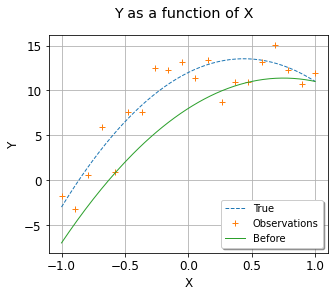

In [9]:
model.setParameter(trueParameter)
graph = model.draw(-1.0, 1.0)
curve = graph.getDrawable(0)
curve.setLegend("True")
curve.setLineStyle("dashed")
graph.setDrawable(curve, 0)
cloud = ot.Cloud(inputObservations, outputObservations)
cloud.setLegend("Observations")
graph.add(cloud)
model.setParameter(candidate)
curve = model.draw(-1.0, 1.0)
curve.setLegends(["Before"])
graph.add(curve)
graph.setColors(ot.Drawable_BuildDefaultPalette(3))
graph.setLegendPosition("bottomright")
view = otv.View(graph, figure_kw={"figsize": (5.0, 4.0)})

On observe que le modèle avant calage est décalé par rapport aux observations. Cela implique que le calage a un travail à réaliser du point de vue de l'ajustement des paramètres $\theta$.

## Calage

Dans cette section, nous réalisons le calage en utilisant la classe `LinearLeastSquaresCalibration`. Pour être certain que le calage est réellement actif et que les paramètres "vrais" sont inconnus du calage, nous configurons les paramètres du calage par la méthode `setParameter` en utilisant les paramètres initiaux contenus dans la variable `candidate`. 

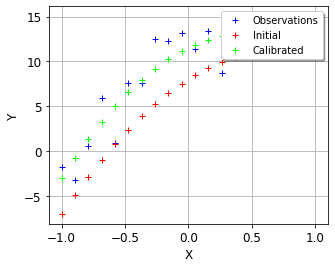

In [10]:
model.setParameter(candidate)  # Met à jour le modèle
algo = ot.LinearLeastSquaresCalibration(
    model, inputObservations, outputObservations, candidate, "SVD"
)
algo.run()
calibrationResult = algo.getResult()
grid = calibrationResult.drawObservationsVsInputs()
graph = grid.getGraph(0, 0)
graph.setXTitle("X")
grid.setGraph(0, 0, graph)
view = otv.View(graph, figure_kw={"figsize": (5.0, 4.0)})

On observe que le modèle après calage est correctement au centre des observations : le calage a réduit les résidus. 

Observons les valeurs des paramètres après calage. 

In [11]:
calibratedParameter = calibrationResult.getParameterMAP()
calibratedParameter

class=Point name=Unnamed dimension=3 values=[11.5451,6.8666,-7.70978]

Rappelons que les vrais paramètres sont 
$$
\boldsymbol{\theta}^\star = (12, 7, -8)^T.
$$
On constate que le calage a produit des paramètres relativement proches des vrais paramètres. 

## Vérifie la distribution des résidus

On souhaite vérifier la distribution des résidus obtenus avec la méthode `getObservationsError`.

In [12]:
residualDistribution = calibrationResult.getObservationsError()
residualDistribution

class=Normal name=Normal dimension=1 mean=class=Point name=Unnamed dimension=1 values=[0] sigma=class=Point name=Unnamed dimension=1 values=[2.26097] correlationMatrix=class=CorrelationMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[1]

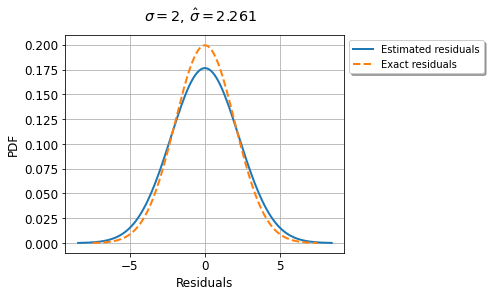

In [13]:
sigma = residualDistribution.getParameter()[1]

graph = residualDistribution.drawPDF()
graphExact = observationOutputNoise.drawPDF().getDrawable(0)
graphExact.setLineStyle("dashed")
graph.add(graphExact)
graph.setTitle("$\sigma=2$, $\hat{\sigma}=%.3f$" % (sigma))
graph.setLegends(["Estimated residuals", "Exact residuals"])
graph.setColors(ot.Drawable_BuildDefaultPalette(2))
graph.setXTitle("Residuals")
view = otv.View(
    graph,
    figure_kw={"figsize": (5.0, 4.0)},
    legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
)

On observe que l'estimation de la distribution des résidus est très proche de la distribution réelle.

In [14]:
rule = ot.GaussKronrodRule(ot.GaussKronrodRule.G11K23)
maximumError = 1.0e-8
maximumSubIntervals = 100
integration_algorithm = ot.GaussKronrod(maximumSubIntervals, maximumError, rule)
algo = otc.HellingerDistanceAlgorithm(residualDistribution, observationOutputNoise)
hellinger_distance = algo.compute_by_integration(integration_algorithm)
print("Hellinger distance=", hellinger_distance)

Hellinger distance= 0.0611888593911075


On observe que la distance est proche de zéro avec une valeur égale à 0.06, ce qui correspond à l'impression visuelle de ces deux distributions relativement proches.

## Convergence selon la taille de l'échantillon

On souhaite observer le comportement de l'estimation lorsque la taille de l'échantillon augmente.

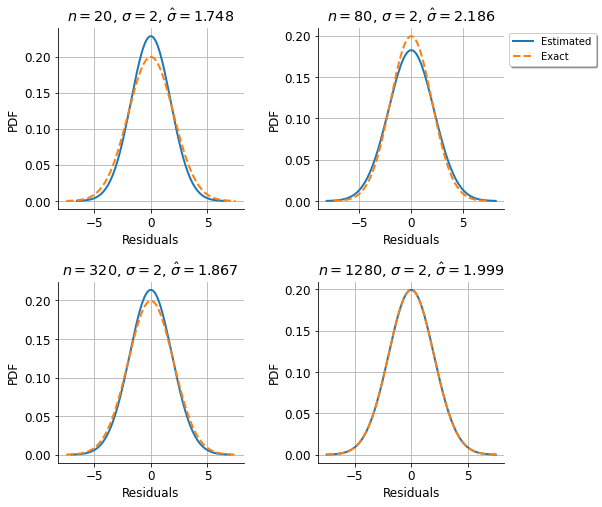

In [15]:
def simulate_and_plot_residuals(size, model, trueParameter, candidate):
    """
    Simule un échantillon et dessine la distribution des résidus.

    Parameters
    ----------
    size : int
        La taille de l'échantillon.

    Returns
    -------
    graph : ot.Graph
        Le graphique des résidus.
    """
    data = np.linspace(-1.0, 1.0, size)
    inputObservations = ot.Sample([[v] for v in data])
    outputObservationNoiseSigma = 2.0
    observationOutputNoise = ot.Normal(0.0, outputObservationNoiseSigma)
    model.setParameter(trueParameter)
    outputStress = model(inputObservations)
    sampleNoiseH = observationOutputNoise.getSample(size)
    outputObservations = outputStress + sampleNoiseH
    model.setParameter(candidate)
    algo = ot.LinearLeastSquaresCalibration(
        model, inputObservations, outputObservations, candidate, "SVD"
    )
    algo.run()
    calibrationResult = algo.getResult()
    calibratedParameter = calibrationResult.getParameterMAP()
    residualDistribution = calibrationResult.getObservationsError()
    sigma = residualDistribution.getParameter()[1]
    graph = residualDistribution.drawPDF()
    graphExact = observationOutputNoise.drawPDF().getDrawable(0)
    graphExact.setLineStyle("dashed")
    graph.add(graphExact)
    graph.setTitle("$n=%d$, $\sigma=2$, $\hat{\sigma}=%.3f$" % (size, sigma))
    graph.setLegends(["Estimated", "Exact"])
    graph.setXTitle("Residuals")
    graph.setColors(ot.Drawable_BuildDefaultPalette(2))
    return graph


grid = ot.GridLayout(2, 2)
graph = simulate_and_plot_residuals(20, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(0, 0, graph)
graph = simulate_and_plot_residuals(80, model, trueParameter, candidate)
grid.setGraph(0, 1, graph)
graph = simulate_and_plot_residuals(320, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(1, 0, graph)
graph = simulate_and_plot_residuals(1280, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(1, 1, graph)
view = otv.View(
    grid,
    figure_kw={"figsize": (8.0, 8.0)},
    legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
)
pl.subplots_adjust(wspace=0.4, hspace=0.4)

On observe que la distribution des résidus converge vers la vraie distribution lorsque la taille de l'échantillon augmente. 

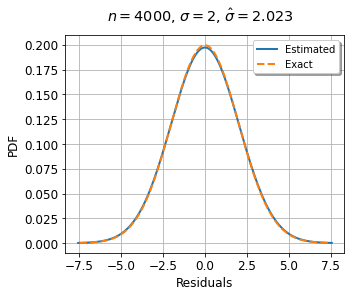

In [16]:
graph = simulate_and_plot_residuals(4000, model, trueParameter, candidate)
view = otv.View(graph, figure_kw={"figsize": (5.0, 4.0)})

Lorsque la taille de l'échantillon augmente, on observe que la distribution des résidus estimés converge vers la vraie distribution du résidu.

## Vérifie la distribution des paramètres

La classe `LinearLeastSquaresCalibrationRandomVector` crée un vecteur aléatoire associé au vecteur des paramètres $\boldsymbol{\theta}$. 

In [17]:
llsqRandomVector = otc.LinearLeastSquaresCalibrationRandomVector(
    model, trueParameter, inputObservations, observationOutputNoise, candidate
)
llsqRandomVector =  ot.RandomVector(llsqRandomVector)
resampleSize = 500
sampleTheta = llsqRandomVector.getSample(resampleSize)
sampleTheta[0:5]

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=5 dimension=3 description=[x0,x1,x2] data=[[11.8087,7.10111,-6.51119],[13.1292,6.89473,-9.90557],[12.3545,6.3511,-9.03584],[11.8399,7.63686,-9.68618],[12.2619,7.04556,-7.9172]]

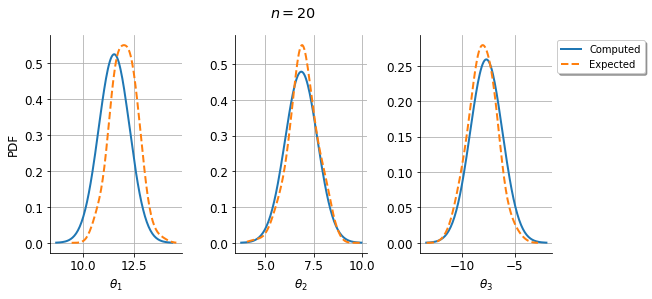

In [18]:
thetaPosterior = calibrationResult.getParameterPosterior()

thetaDistribution = ot.KernelSmoothing().build(sampleTheta)
grid = ot.GridLayout(1, parameterDimension)
for i in range(parameterDimension):
    thetai = thetaPosterior.getMarginal(i)
    graph = thetai.drawPDF()
    graph.setLegends(["Computed"])
    # From data
    curve = thetaDistribution.getMarginal(i).drawPDF()
    curve = curve.getDrawable(0)
    curve.setLegend("Expected")
    curve.setLineStyle("dashed")
    graph.add(curve)
    if i != parameterDimension - 1:
        graph.setLegends([""])
    if i != 0:
        graph.setYTitle("")
    graph.setColors(ot.Drawable_BuildTableauPalette(3))
    grid.setGraph(0, i, graph)
grid.setTitle("$n=%d$" % (size))
view = otv.View(
    grid,
    figure_kw={"figsize": (9.0, 4.0)},
    legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
)
pl.subplots_adjust(wspace=0.4, hspace=0.4)

On observe que les deux distributions sont proches. La différence dans l'estimation du centre est dûe à la taille limitée de l'échantillon. La variance est correctement estimée.

On peut calculer la distance de Hellinger entre la loi estimée par calage et la loi estimée par ré-échantillonnage.

In [19]:
ksdist = ot.KernelSmoothing().build(sampleTheta)
dimension = sampleTheta.getDimension()
integration_algorithm = ot.GaussLegendre([30] * dimension)
algo = otc.HellingerDistanceAlgorithm(thetaPosterior, ksdist)
hellinger_distance = algo.compute_by_integration(integration_algorithm)
print("Hellinger distance=", hellinger_distance)

Hellinger distance= 0.291421342109231


Avec une distance égale à 0.29, on pourrait penser que les deux distributions ne sont pas très proches. Ce n'est toutefois pas l'impression visuelle que donne la comparaison des lois marginales. Cette différence d'appréciation est peut-être dûe au fait que la distance de Hellinger considère deux distributions en dimension 3 alors que nous visualisons et comparons les 3 densités de probabilité marginales.

## Convergence selon la taille de l'échantillon

On souhaite observer le comportement de l'estimation lorsque la taille de l'échantillon augmente.

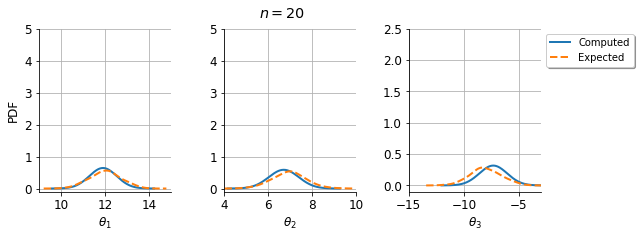

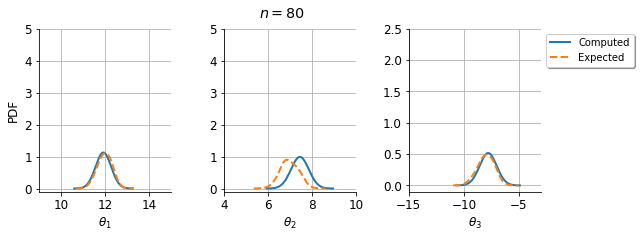

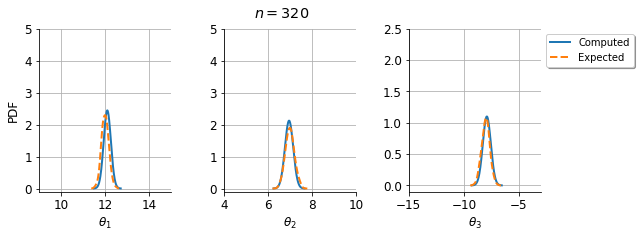

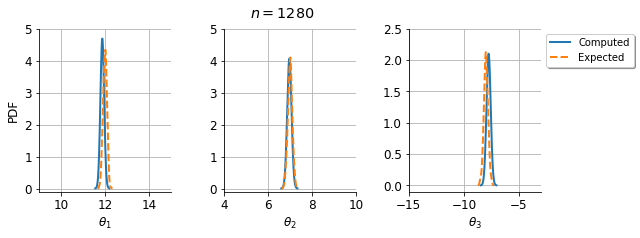

In [20]:
def simulate_and_plot_parameter(size, resampleSize=500):
    trueParameter = ot.Point([12.0, 7.0, -8.0])
    outputObservationNoiseSigma = 2.0  # (Pa)
    observationOutputNoise = ot.Normal(0.0, outputObservationNoiseSigma)
    data = np.linspace(-1.0, 1.0, size)
    inputObservations = ot.Sample([[v] for v in data])

    model.setParameter(trueParameter)
    outputSample = model(inputObservations)

    outputError = observationOutputNoise.getSample(size)
    outputObservations = outputSample + outputError

    candidate = ot.Point([8.0, 9.0, -6.0])

    model.setParameter(candidate)
    algo = ot.LinearLeastSquaresCalibration(
        model, inputObservations, outputObservations, candidate, "SVD"
    )
    algo.run()
    calibrationResult = algo.getResult()
    theta = calibrationResult.getParameterMAP()

    thetaPosterior = calibrationResult.getParameterPosterior()

    covarianceThetaStarOT = thetaPosterior.getCovariance()

    llsqRandomVector = otc.LinearLeastSquaresCalibrationRandomVector(
        model, trueParameter, inputObservations, observationOutputNoise, candidate
    )
    llsqRandomVector =  ot.RandomVector(llsqRandomVector)
    sampleTheta = llsqRandomVector.getSample(resampleSize)

    thetaDistribution = ot.KernelSmoothing().build(sampleTheta)
    grid = ot.GridLayout(1, parameterDimension)
    list_of_bounding_boxes = [
        ot.Interval([9.0, -0.1], [15.0, 5.0]),
        ot.Interval([4.0, -0.1], [10.0, 5.0]),
        ot.Interval([-15.0, -0.1], [-3.0, 2.5]),
    ]
    for i in range(parameterDimension):
        thetai = thetaPosterior.getMarginal(i)
        graph = thetai.drawPDF()
        graph.setLegends(["Computed"])
        # From data
        curve = thetaDistribution.getMarginal(i).drawPDF()
        curve = curve.getDrawable(0)
        curve.setLegend("Expected")
        curve.setLineStyle("dashed")
        graph.add(curve)
        graph.setColors(ot.Drawable_BuildTableauPalette(3))
        if i > 0:
            graph.setYTitle("")
        if i != parameterDimension - 1:
            graph.setLegends([""])
        graph.setBoundingBox(list_of_bounding_boxes[i])
        grid.setGraph(0, i, graph)
    grid.setTitle("$n=%d$" % (size))
    view = otv.View(
        grid,
        figure_kw={"figsize": (9.0, 3.0)},
        legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
    )
    pl.subplots_adjust(wspace=0.4, hspace=0.4)
    return view


view = simulate_and_plot_parameter(20)
view = simulate_and_plot_parameter(80)
view = simulate_and_plot_parameter(320)
view = simulate_and_plot_parameter(1280)

On observe que la distribution est de plus en plus resserrée lorsque la taille de l'échantillon augmente.